# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

|    Group   |           61          |
|------------|----------------------|
| Student A  |        Eva Miesen (5705304) |
| Student B  |        Iasonas Chronis (6167608) |
| Student C  |        Guy Barel (6124607) |
| Student D  |        Miłosz Dudała (6212743) |

#### Imports

In [3]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

#### Seed

In [4]:
# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [5]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.

        Args: 
            agent (Agent): The agent to select an action for
            maze (Maze): The maze to select an action for

        Returns:
            Action: A random valid action
        """
        valid_actions = agent.get_valid_actions(maze)
        return valid_actions[np.random.randint(len(valid_actions))] # Randomly select a valid action

    def e_greedy(self, agent: Agent, maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.

        Args:
            agent (Agent): The agent to select an action for
            maze (Maze): The maze to select an action for
            eps (float): The probability of selecting a random action

        Returns:
            Action: A random valid action
        """
        valid_actions = agent.get_valid_actions(maze)

        # Randomly select an action with probability eps
        if np.random.random() < eps:
            return valid_actions[np.random.randint(len(valid_actions))]

        # Select the action with the highest q-value
        state = agent.get_state(maze)
        q_values = np.array([self.q_table.get_q(state, a) for a in valid_actions])
        best_indices = np.where(q_values == q_values.max())[0] # A tie-breaker that allows us to select randomly between multiple best actions

        return valid_actions[np.random.choice(best_indices)]

    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured.

        Args:
            agent (Agent): The agent to select an action for
            maze (Maze): The maze to select an action for
            temperature (float): The temperature of the Boltzmann distribution

        Returns:
            Action: A random valid action
        """
        valid_actions = agent.get_valid_actions(maze)
        state = agent.get_state(maze)
        q_values = np.array([self.q_table.get_q(state, a) for a in valid_actions], dtype=float)

        # Subtract max for numerical stability before exponentiation
        q_shifted = q_values - q_values.max()
        exp_q = np.exp(q_shifted / temperature)
        probabilities = exp_q / exp_q.sum()
        chosen_idx = np.random.choice(len(valid_actions), p=probabilities)
        
        return valid_actions[chosen_idx]

**Random exploration** selects a valid action uniformly at random, every valid action has equal probability of being chosen. This ensures maximum exploration but ignores any learned information, making it inefficient once the agent starts accumulating knowledge.

**ε-greedy exploration** selects a random action with probability $ε$ (exploration) and the highest-Q action with probability $1 − ε$ (exploitation). It provides a simple and effective balance between the two. We use `ε = 0.1` as the initial value, so the agent explores 10% of the time while mostly following what it has learned.

**Boltzmann exploration** (softmax) assigns probabilities to all valid actions proportional to their exponentiated Q-values scaled by temperature T:
- High T → near-uniform distribution (exploration)
- Low T → probability concentrated on the best action (exploitation)

Unlike **ε-greedy**, it considers relative Q-value magnitudes when exploring, making it a softer tradeoff. We use `T = 1.0` as the initial temperature.

To ensure sufficient exploration in early episodes and increasing exploitation over time, both `ε` and `T` can be decayed during training. This motivates the exploration-heavy start that allows the agent to discover the goal, followed by convergence to the optimal policy as knowledge is refined.

#### Question 2

In [120]:
def run_single_run(maze_path, goal_x, goal_y, n_steps, learner=None, strategy='e_greedy',
                    eps=0.1, temperature=1.0):
    """
    Runs one complete training run, stopping when total steps across all episodes >= n_steps.
    Returns a list of episode lengths (steps per episode).
    
    Args:
        maze_path (str): The path to the maze file
        goal_x (int): The x-coordinate of the goal
        goal_y (int): The y-coordinate of the goal
        n_steps (int): The maximum number of steps to run
        learner (QLearning or SARSA): The learning algorithm to use
        strategy (str): The exploration strategy to use
        eps (float): The probability of selecting a random action
        temperature (float): The temperature of the Boltzmann distribution

    Returns:
        list: A list of episode lengths (steps per episode)
    """
    maze = Maze(maze_path)
    maze.set_reward(x=goal_x, y=goal_y, reward=10)
    maze.set_terminal(x=goal_x, y=goal_y)
    agent = Agent(start_x=0, start_y=0)
    actions = [Action(a_id) for a_id in ["up", "down", "left", "right"]]
    q_table = QTable(maze.get_all_states(), actions)
    strat = ExplorationStrategy(q_table)

    episode_lengths = []
    total_steps = 0

    # Main training loop
    while total_steps < n_steps:
        agent.reset()
        done = False

        # Episode loop
        while not done:
            state = agent.get_state(maze)

            # Select action according to the chosen strategy
            if strategy == 'random':
                action = strat.random(agent, maze)
            elif strategy == 'boltzmann':
                action = strat.boltzmann(agent, maze, temperature)
            else:
                action = strat.e_greedy(agent, maze, eps)               # Default: e_greedy

            # Execute action in the environment
            next_state, reward, done = agent.step(action, maze)

            if learner is not None:
                valid_actions = agent.get_valid_actions(maze)
                if learner.__class__.__name__ == "QLearning":
                    learner.learn(valid_actions, state, action, next_state, reward, done)
                elif learner.__class__.__name__ == "SARSA":
                    old_x, old_y = agent.x, agent.y                                         # Save agent's current position
                    agent.x, agent.y = next_state.x, next_state.y                           # Move agent to the next_state
                    # next_valid_actions = agent.get_valid_actions(maze)
                    
                    next_action = strat.e_greedy(agent, maze, eps)                          # Choose next action using the same policy (e.g., e_greedy)
                    agent.x, agent.y = old_x, old_y                                         # Restore agent's original position
                    learner.learn(state, action, next_state, next_action, reward, done)
            total_steps += 1
            
        episode_lengths.append(agent.nr_of_actions_since_reset)

    return episode_lengths

In [121]:
# Create a Maze instance
maze = Maze("./../data/toy_maze.txt")           # Changed from easy_maze.txt to toy_maze.txt
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)

# Create an Agent
agent = Agent(start_x=0, start_y=0)

# Create a QTable
states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)

# Create an ExplorationStrategy
exploration_strategy = ExplorationStrategy(q_table)

# Create a learner
params = {"lr": 0.7, "gamma": 0.9} # learner = QLearning(q_table, params)

# Hyper-parameters
n_episodes = 300
episode_lengths = []
episode_rewards = []

for episode in tqdm(range(n_episodes)):
    # Reset the agent to the start position at the beginning of each episode
    agent.reset()
    done = False
    episode_reward = 0

    # Iterate until the agent reaches the goal
    while not done:
        # Observation: Where am I?
        state = agent.get_state(maze)

        # Decision: What to do?
        action = exploration_strategy.e_greedy(agent, maze, eps=0.1)

        # Execution: Move and observe
        next_state, reward, done = agent.step(action, maze)
        
        episode_reward += reward # no learner, Q-table is not updated here
    
    # Store the episode length and reward
    episode_lengths.append(agent.nr_of_actions_since_reset)
    episode_rewards.append(episode_reward)

100%|██████████| 300/300 [00:04<00:00, 72.64it/s]


The agent cycle consists of the following steps, which repeat until an episode terminates:

1. **Reset:** At the start of each episode the agent is placed back at its starting position. This is necessary to begin a fresh trial from a consistent state.
2. **Get current state:** The agent reads its current `(x, y)` position in the maze. This is needed because the action selection and Q-table update both depend on knowing the current state.
3. **Select action:** An action is chosen using the exploration strategy (here `ε-greedy`). This maps the current state to an action via the policy $π$, which is how the agent decides what to do next.
4. **Execute action:** `agent.step(action, maze)` moves the agent and returns `(next_state, reward, done)`. This step is the agent's interaction with its environment, it receives feedback in the form of a reward and a new state.
5. **Update Q-table** (omitted here, no learner yet)**:** In later questions, this is where the learning algorithm updates $Q(s, a)$ based on the observed transition, without it the agent cannot improve.
6. **Record episode length:** After the episode ends (terminal state reached), the number of steps taken is stored, this is used to monitor learning progress.

No additional steps are needed, the `Agent` class internally tracks position and step count, `Maze` handles reward and terminal queries, and `QTable` stores Q-values. These responsibilities are cleanly separated, so the cycle itself only needs to orchestrate them.

#### Question 3

In [122]:
# Run the agent with a step budget
N_STEPS = 30_000
toy_maze_path = "./../data/toy_maze.txt"

episode_lengths_q3 = run_single_run(
    maze_path=toy_maze_path,
    goal_x=9,
    goal_y=9,
    n_steps=N_STEPS,
    strategy='e_greedy',
    eps=0.1
)

total_steps_taken = sum(episode_lengths_q3)

# Print the results
print(f"Number of episodes completed: {len(episode_lengths_q3)}")
print(f"Total steps taken: {total_steps_taken}")
print(f"Step budget (n_steps): {N_STEPS}")
print(f"Overshoot (last episode): {total_steps_taken - N_STEPS}")

Number of episodes completed: 30
Total steps taken: 32412
Step budget (n_steps): 30000
Overshoot (last episode): 2412


The stopping criterion is implemented in the `run_single_run` helper. A `total_steps` counter is incremented at each step, and the outer loop exits as soon as `total_steps >= n_steps`. Because we check the budget after each step (and always allow the agent to fully finish the episode it's on), the total will exceed `n_steps` by a fraction of the length of that final episode. Running the agent with `n_steps = 30,000` on the toy maze confirms this, the printed total is > 30,000, with the overshoot representing the number of steps that last episode dragged on past our budget. The large step budget relative to the maze size ensures the agent completes many episodes before stopping.

#### Question 4

In [123]:
def run_experiment(maze_path, goal_x, goal_y, n_steps, n_runs,
                   learner=None, strategy='e_greedy', eps=0.1, temperature=1.0):
    """
    Runs n_runs independent runs (each up to n_steps total steps) and returns a
    list of episode-length lists, one per run.

    Args:
        maze_path (str): The path to the maze file
        goal_x (int): The x-coordinate of the goal
        goal_y (int): The y-coordinate of the goal
        n_steps (int): The maximum number of steps to run
        n_runs (int): The number of independent runs to perform
        learner (QLearning or SARSA): The learning algorithm to use
        strategy (str): The exploration strategy to use
        eps (float): The probability of selecting a random action
        temperature (float): The temperature of the Boltzmann distribution

    Returns:
        list: A list of episode-length lists, one per run
    """
    all_lengths = []

    # Run the experiment n_runs times
    for _ in range(n_runs):
        lengths = run_single_run(
            maze_path=maze_path,
            goal_x=goal_x,
            goal_y=goal_y,
            n_steps=n_steps,
            learner=learner,
            strategy=strategy,
            eps=eps,
            temperature=temperature
        )
        all_lengths.append(lengths)

    return all_lengths


def pad_and_aggregate(all_lengths):
    """
    Pads runs to the same length with NaN, then returns per episode mean and std.
    Runs with fewer episodes contribute NaN, so nanmean/nanstd ignore them.

    Args:
        all_lengths (list): A list of episode-length lists, one per run

    Returns:
        tuple: A tuple containing the mean and standard deviation of the episode lengths
    """
    # Find the maximum number of episodes across all runs
    max_ep = max(len(r) for r in all_lengths)

    # Create a padded array with NaN values
    padded = np.full((len(all_lengths), max_ep), np.nan)

    # Pad runs to the same length with NaN
    for i, r in enumerate(all_lengths):
        padded[i, :len(r)] = r

    mean = np.nanmean(padded, axis=0)
    std = np.nanstd(padded, axis=0)

    return mean, std

Toy maze:
  run 1: [1216, 3296, 2488, 1818, 292, 1316, 1910, 640, 1280, 440, 674, 190, 986, 5522, 5220, 5088]
  run 2: [908, 178, 638, 554, 124, 984, 1046, 1652, 1034, 874, 1608, 1172, 1852, 578, 1232, 134, 1562, 588, 2514, 1500, 3758, 1636, 1512, 288, 330, 184, 2612]
  run 3: [556, 676, 1744, 3626, 146, 316, 2016, 2040, 218, 1392, 604, 642, 426, 662, 1100, 194, 208, 946, 988, 496, 330, 232, 2344, 1776, 5464, 644, 996]
  run 4: [3144, 1218, 1250, 1204, 1480, 232, 498, 798, 652, 670, 2048, 1352, 1562, 372, 444, 594, 2366, 2160, 4728, 1856, 1150, 2878]
  run 5: [864, 332, 4474, 2134, 326, 154, 422, 944, 668, 544, 2414, 2210, 3172, 1972, 1672, 464, 686, 382, 680, 56, 1404, 1870, 696, 1458, 484]
  run 6: [1050, 1186, 2194, 1412, 1614, 3122, 310, 1854, 486, 536, 1636, 676, 398, 778, 344, 1004, 816, 284, 3844, 550, 290, 2860, 118, 526, 1280, 1614]
  run 7: [268, 2012, 362, 112, 808, 1736, 1750, 1334, 508, 1680, 506, 658, 498, 1070, 2062, 1216, 186, 2234, 406, 570, 1320, 4266, 2732, 578, 644,

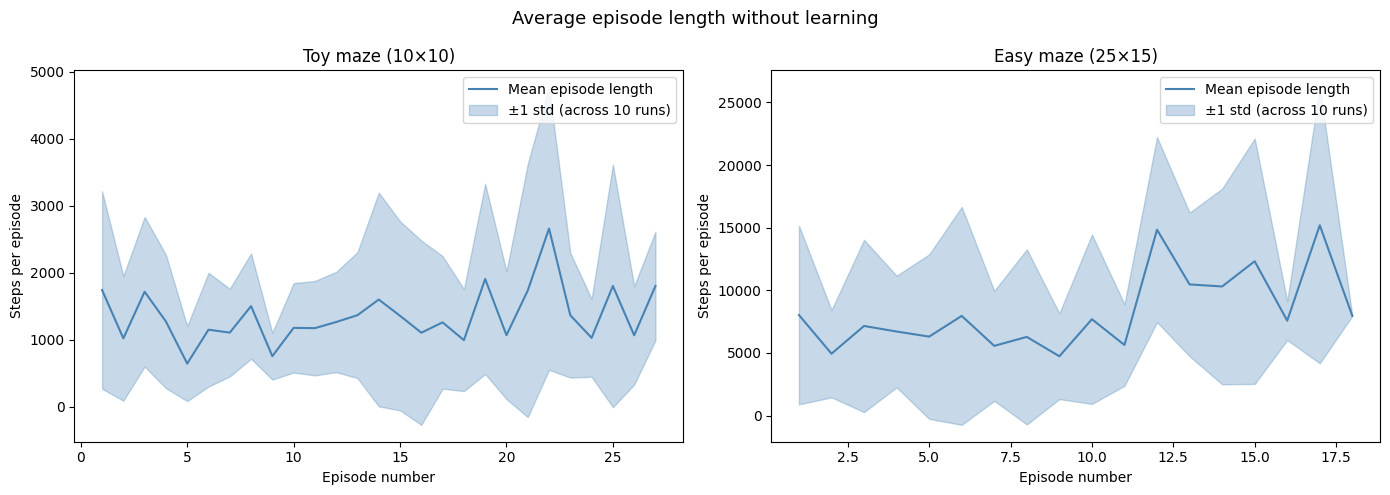

In [124]:
N_RUNS = 10
N_STEPS_TOY  = 30_000
N_STEPS_EASY = 100_000                      # Larger maze needs more steps

toy_path  = "./../data/toy_maze.txt"
easy_path = "./../data/easy_maze.txt"

# Run experiments
toy_lengths  = run_experiment(toy_path,  goal_x=9,  goal_y=9,  n_steps=N_STEPS_TOY,  n_runs=N_RUNS)
easy_lengths = run_experiment(easy_path, goal_x=24, goal_y=14, n_steps=N_STEPS_EASY, n_runs=N_RUNS)

# Print the episode lengths per run
print("Toy maze:")
for i, ep_lens in enumerate(toy_lengths):
    print(f"  run {i+1}:", ep_lens)

print("Easy maze:")
for i, ep_lens in enumerate(easy_lengths):
    print(f"  run {i+1}:", ep_lens)

toy_mean,  toy_std  = pad_and_aggregate(toy_lengths)
easy_mean, easy_std = pad_and_aggregate(easy_lengths)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Average episode length without learning", fontsize=13)

# Plot the results
for ax, mean, std, title, n_ep in [
    (axes[0], toy_mean,  toy_std,  "Toy maze (10×10)",  len(toy_mean)),
    (axes[1], easy_mean, easy_std, "Easy maze (25×15)", len(easy_mean)),
]:
    episodes = np.arange(1, n_ep + 1)
    ax.plot(episodes, mean, label="Mean episode length", color="steelblue")
    ax.fill_between(episodes, mean - std, mean + std, alpha=0.3,
                    color="steelblue", label="±1 std (across 10 runs)")
    ax.set_title(title)
    ax.set_xlabel("Episode number")
    ax.set_ylabel("Steps per episode")
    ax.legend()

plt.tight_layout()
plt.show()

The plots in show the average number of steps per episode across 10 independent runs, with the shaded region indicating ±1 standard deviation.

As expected, without a learning algorithm the episode lengths show **no decreasing trend**, they remain high and noisy throughout training. This is because the Q-table is never updated. All Q-values stay at their initial value of zero, so the ε-greedy strategy effectively selects actions randomly. The agent therefore cannot exploit past experience to shorten its path to the goal.

For the toy maze, the average episode is very long relative to the optimal path, and the variance is high since the random walk may take very different routes each time. The easy maze shows similarly erratic behaviour, but with even longer episodes due to its larger size and more complex structure.

The shaded bands capture inter-run variability. Where runs produce different numbers of episodes (due to variation in episode length), shorter runs are padded with `NaN` so that the mean is computed only over available runs at each episode index, this keeps the plot meaningful even when episode counts differ across runs.

#### Question 5

In [125]:
alpha = 0.7
gamma = 0.9
epsilon = 0.1

In [126]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        
        old_value = self.q_table.get_q(state, action)                               # Get old value of current state from the table
        
        if done:
            next_state_value = 0                                                    # If terminal state, value is 0
        else: 
            next_state_value = max(self.q_table.get_q(next_state, a)                # Take the best future value for a in possible_actions)
                                     for a in possible_actions)             
                                     
        # Calculate new_value using equation 1.1
        new_value = old_value + alpha * (reward + (gamma * next_state_value) - old_value)
        self.q_table.set_q(state, action, new_value)                                # Set new_value in table

In [127]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        
        old_value = self.q_table.get_q(state, action)                               # Get old value of current state from the table

        if done:                                                                    # If terminal state, value is 0
            next_state_value = 0                                                    
        else:
            next_state_value = self.q_table.get_q(next_state, next_action)          # Take the value of the next state and next action
        
        # SARSA update using equation 1.2
        new_value = old_value + alpha * (reward + (gamma * next_state_value) - old_value)
        self.q_table.set_q(state, action, new_value)                                # Store new_value in table

# TODO: Add explanation

# Where should I use epsilon?

#### Question 6

In [128]:

#TODO: Add proper documentation and comments
#TODO: maybe optimise

def prep_states_action(path: str, goal_x: int, goal_y: int):
    maze = Maze(path)
    maze.set_terminal(goal_x, goal_y)
    states = [s for s in maze.get_all_states() if s.type == "path"]
    actions = [Action(a_id) for a_id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    params = {"alpha": 0.1, "gamma": 0.99}
    return q_table, params

def make_qlearner(q_table: QTable, params: Dict[str, float]):
    return QLearning(q_table, params)

# TODO Remove when done: Remember: need seperates methods for qlearning and sarsa since we need fresh learners for every run
def run_with_qlearning(path: str, goal_x: int, goal_y: int, n_steps: int):
    all_lengths = []
    for _ in range(N_RUNS):         
        q_table, params = prep_states_action(path, goal_x, goal_y)    # Prepare the q_table and parameters (alpha and gamma)
        learner = make_qlearner(q_table, params)                      # Fresh learner each run
        lengths = run_single_run(
            maze_path=path,
            goal_x=goal_x,
            goal_y=goal_y,
            n_steps=n_steps,
            learner=learner,
            strategy='e_greedy',
            eps=epsilon
        )
        all_lengths.append(lengths)
    return all_lengths


# Run agent with QLearning on the mazes, average of 10 runs each
q_toy_lengths  = run_with_qlearning(toy_path,  9,  9,  N_STEPS_TOY)
q_easy_lengths = run_with_qlearning(easy_path, 24, 14, N_STEPS_EASY)

In [129]:
def make_slearner(q_table: QTable, params: Dict[str, float]):
    return SARSA(q_table, params)

def run_with_sarsa(path: str, goal_x: int, goal_y: int, n_steps: int):
    all_lengths = []
    for _ in range(N_RUNS):
        q_table, params = prep_states_action(path, goal_x, goal_y)      # Prepare the q_table and parameters (alpha and gamma)
        learner = make_slearner(q_table, params)                        # Fresh learner each run
        lengths = run_single_run(
            maze_path=path,
            goal_x=goal_x,
            goal_y=goal_y,
            n_steps=n_steps,
            learner=learner,
            strategy='e_greedy',
            eps=epsilon
        )
        all_lengths.append(lengths)
    return all_lengths

# Run agent with SARSA on the mazes, average of 10 runs each
s_toy_lengths  = run_with_sarsa(toy_path,  9,  9,  N_STEPS_TOY)
s_easy_lengths = run_with_sarsa(easy_path, 24, 14, N_STEPS_EASY)


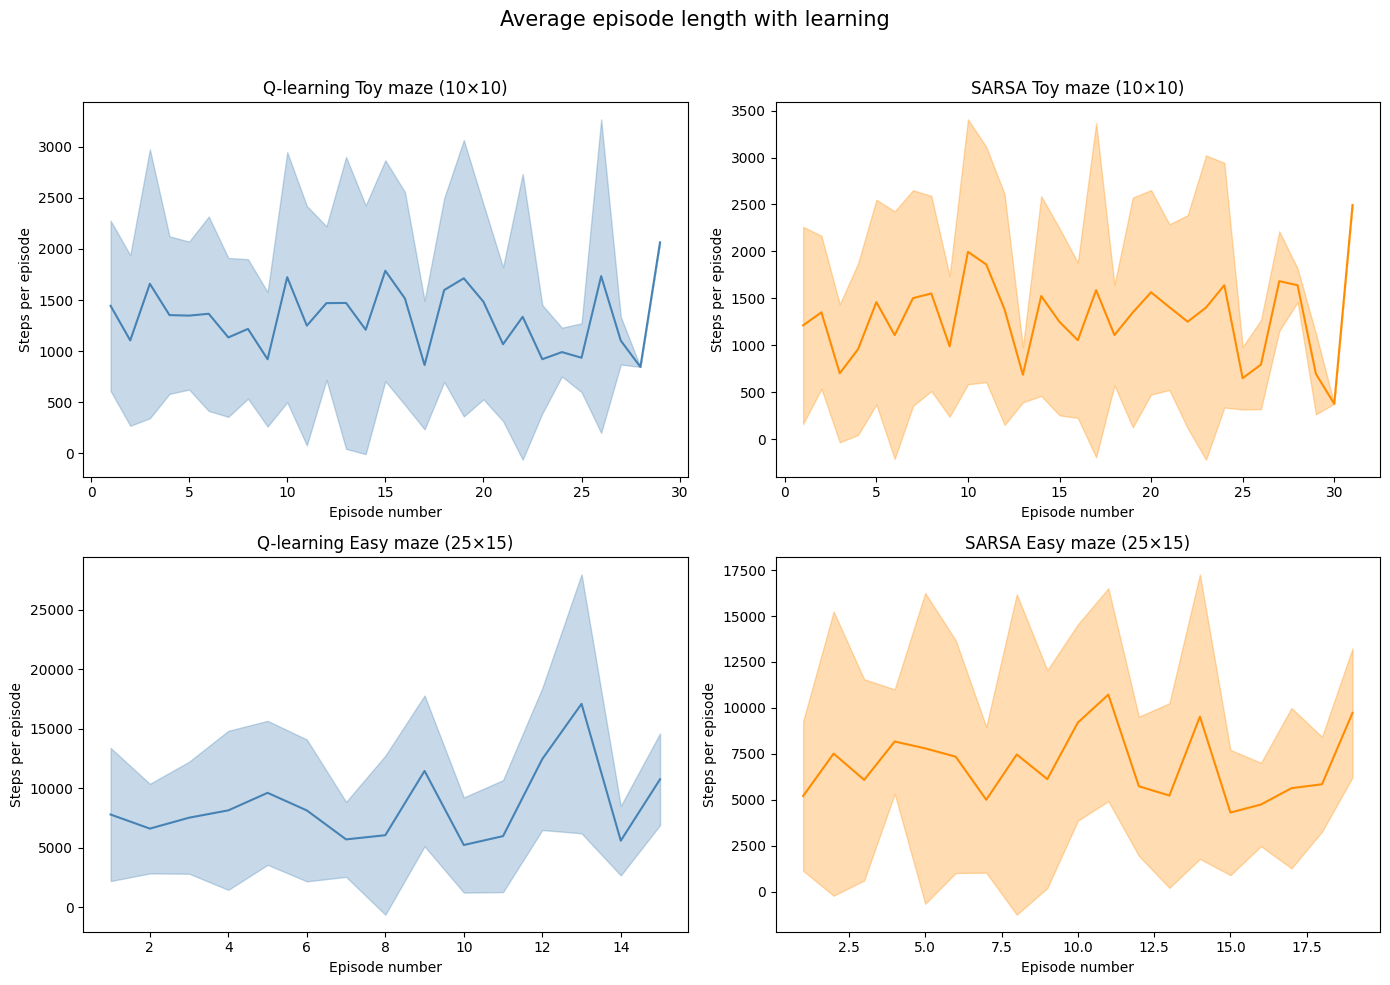

In [132]:
q_toy_mean,  q_toy_std  = pad_and_aggregate(q_toy_lengths)
q_easy_mean, q_easy_std = pad_and_aggregate(q_easy_lengths)

s_toy_mean,  s_toy_std  = pad_and_aggregate(s_toy_lengths)
s_easy_mean, s_easy_std = pad_and_aggregate(s_easy_lengths)

# Plot the results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Average episode length with learning", fontsize=15)

# Data for each subplot
maze_data = [
    (axes[0, 0], q_toy_mean, q_toy_std, "Q-learning Toy maze (10×10)"),
    (axes[0, 1], s_toy_mean, s_toy_std, "SARSA Toy maze (10×10)"),
    (axes[1, 0], q_easy_mean, q_easy_std, "Q-learning Easy maze (25×15)"),
    (axes[1, 1], s_easy_mean, s_easy_std, "SARSA Easy maze (25×15)")
]

for ax, mean, std, title in maze_data:
    episodes = np.arange(1, len(mean) + 1)
    ax.plot(episodes, mean, color="steelblue" if "Q-learning" in title else "darkorange")
    ax.fill_between(episodes, mean - std, mean + std,
                    alpha=0.3, color="steelblue" if "Q-learning" in title else "darkorange")
    ax.set_title(title)
    ax.set_xlabel("Episode number")
    ax.set_ylabel("Steps per episode")

plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
plt.show()

# TODO: Add explanation

#### Question 7: Do you observe any differences between robots trained using QLearning and SARSA? Why is that the case?

# TODO

### 2.2 Optimization
#### Question 8

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 9: What are the trade-offs between high and low values of ϵ?

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 10: Choose at least five different values for the hyper-parameter T for Boltzmann exploration. What seem to be the trade-offs between high and low values?

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 11: Using your insights from the tuning of ϵ and T, compare the performance of the three exploration strategies. Which one performs best? Why do you think that is the case?

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 12: Finally, play around with the learning rate α for QLearning. Again, choose a value of α between 0 and 1 at least five times. Make a plot for each of these values. Explain what you notice. Why is that the case?

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.3 Introducing More Rewards
#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 14: Does switching from QLearning to SARSA help us solve the problem from above? Why?

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17: Give at least one downside of an algorithm that is greedy with its action selection.

These are some downsides of an algorithm that is greedy with its action selection:
- **Stuck in local optimal**: Because a greedy algorithm always selects the action that appears best at the current moment (without considering future consequences), it may converge to a suboptimal solution instead of finding the true optimum.
- **Lack of exploration**: A greedy algorithm does not try alternative actions once a preference is formed. If an action is initially underestimated, the algorithm will not try it out again, and thus might miss out better options.
- **Sensitive to initial estimates**: Poor initial value estimates can strongly bias the algorithm and thus early mistakes may lead to consistently choosing suboptimal actions.

#### Question 18: When and why can reward functions cause problems in the society? Think in terms of agents “understanding” the point of their reward functions.

Reward functions can cause problems in society when agents optimise them in unintended ways, effectively "misunderstanding" the true goal behind the optimisation. Since an agent only tries to maximise the reward, it may exploit loopholes or shortcuts that technically increase the reward, but lead to undesirable or harmful outcomes.

An example of is an automonous delivery drone that is rewarded solely for speed in completing deliveries. To maximise th reward, the drone might take unsafe shortcuts, fly in restricted areas or igrnore traffic rules. While the reward function (fast deliveries) is technically satisfied, the true goal of safe and reliable delivery is compromised. This example illustrates that if an agent only focusses on the explicit reward, it can behave in harmful or socially unacceptable ways, even though it is doing a good job when solely looking at the reward function.

#### Question 19: Can you think of a way to overcome these problems for reward functions, used in practice?

One way to overcome these problems is to use multiple objectives alongside the main reward. For example, in the delivery drone scenario, the reward could combine speed of delivery with safety compliance and adherence to regulations. This ensures that maximising the reward requires the agent to balance all desired outcomes, reducing the likelihood of unsafe shortcuts or rule violations.

Another approach is to use human feedback, where an agent's reward is adjusted based on how well its behaviour aligns with human intentions. This helps guid the agent toward actions that achieve the intended goals rather than exploiting loopholes in the reward function.

### 3.2 Pen and Paper
#### Question 20

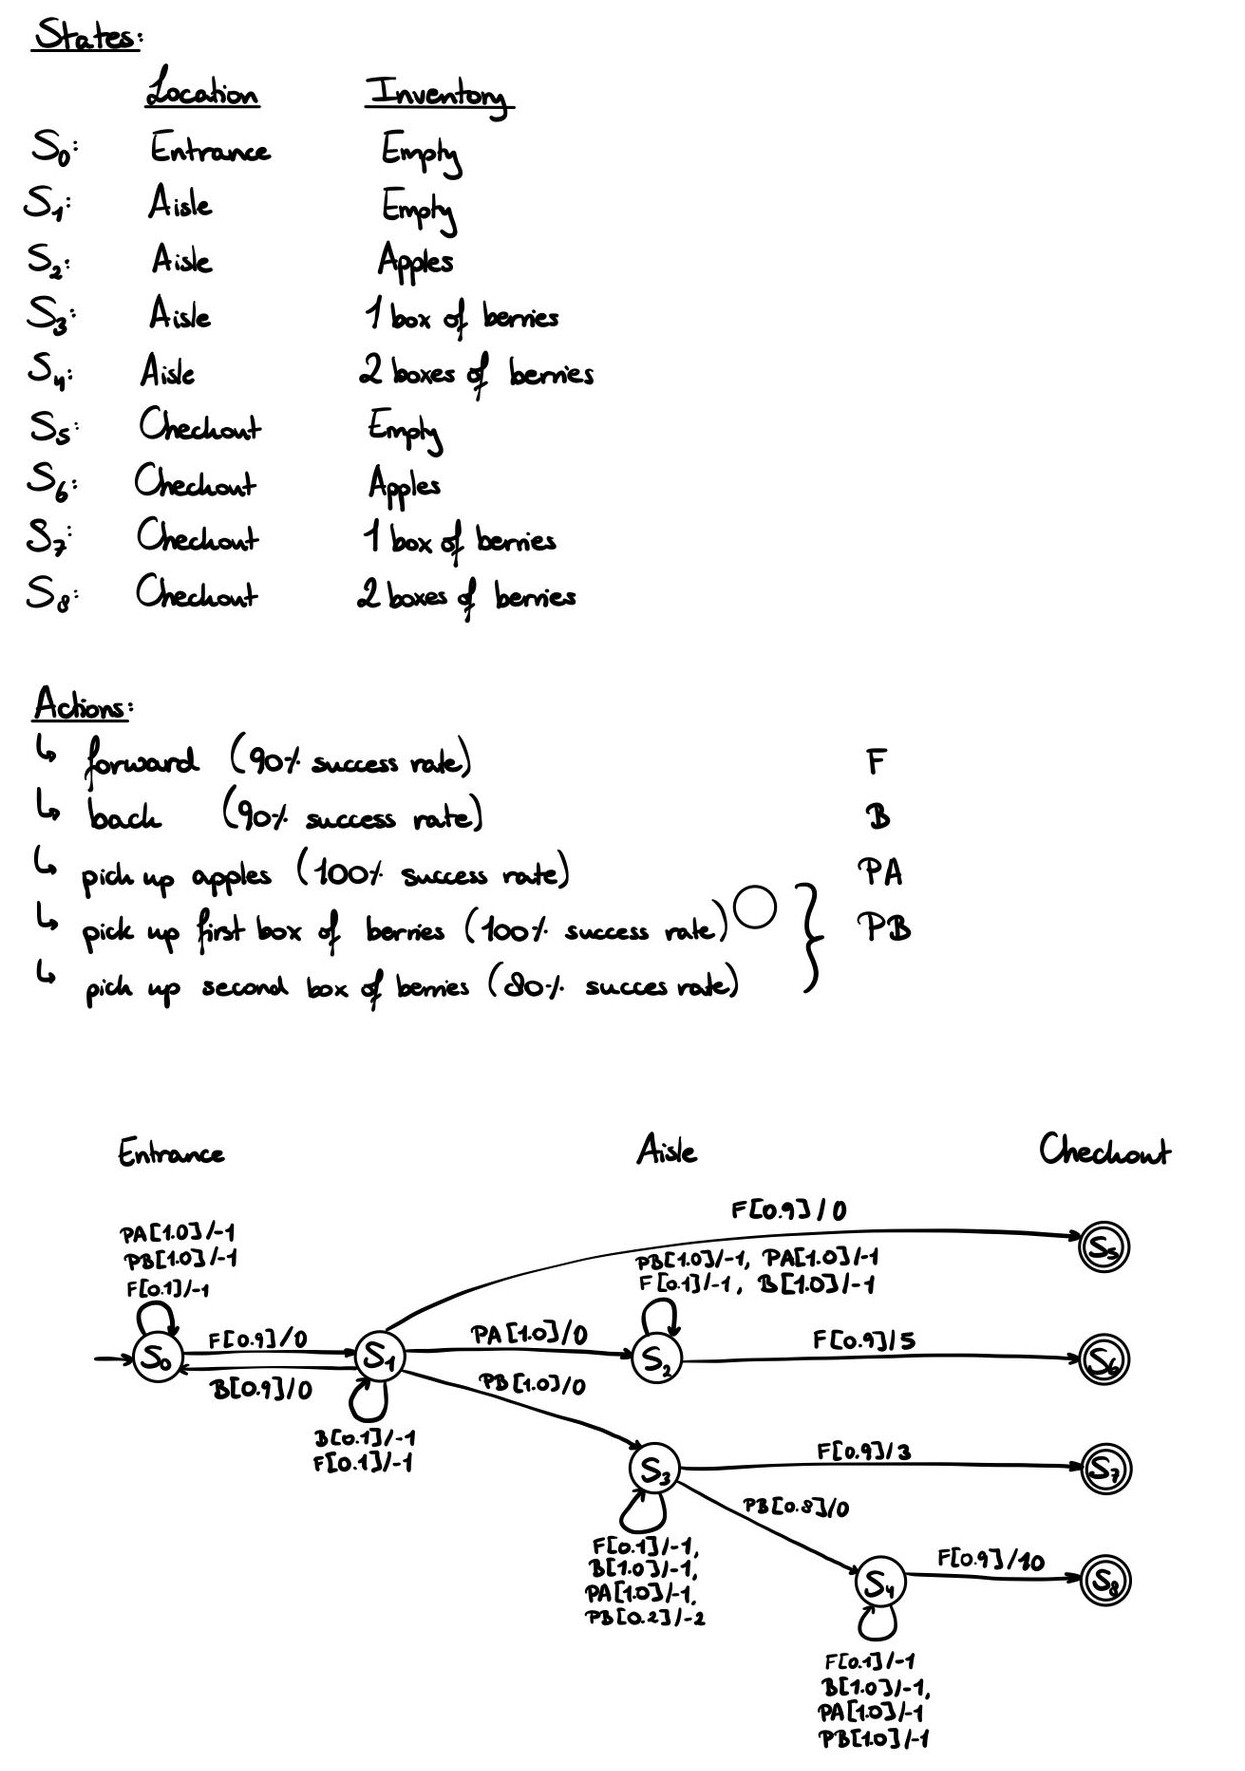

#### Question 21

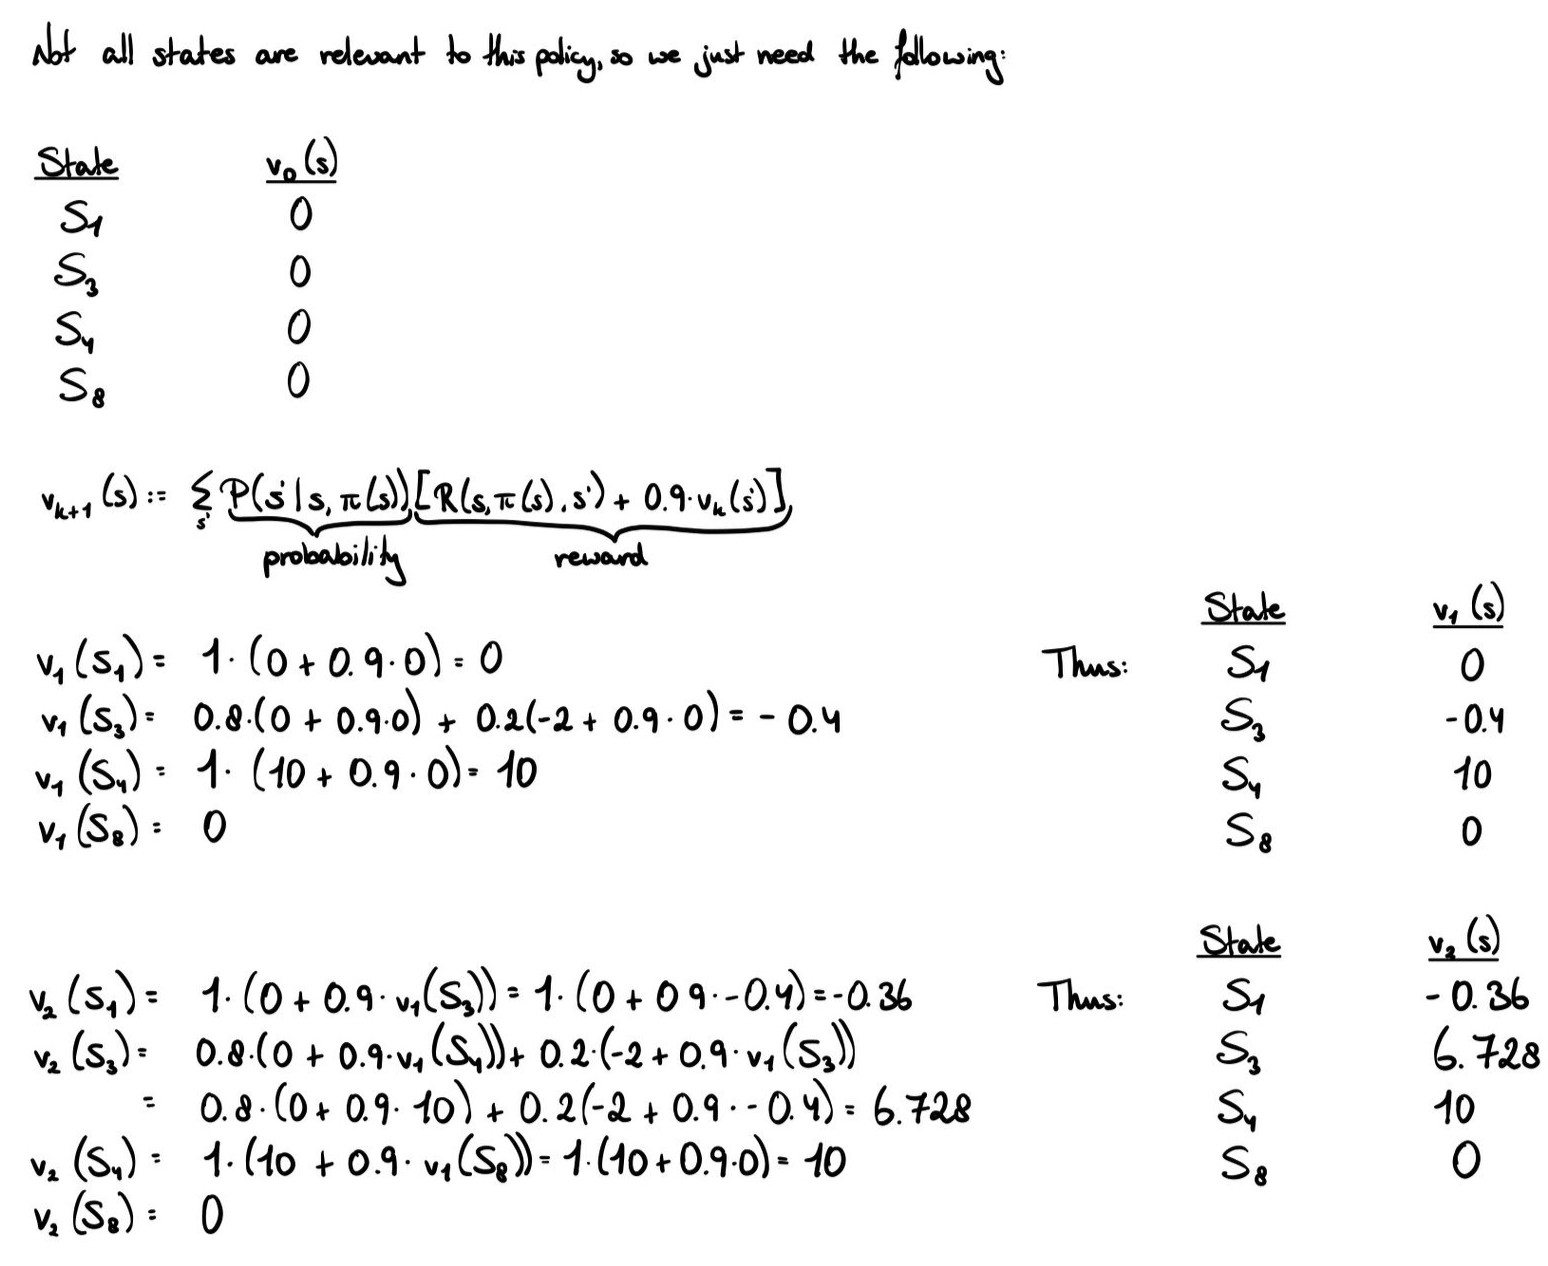

#### Question 22

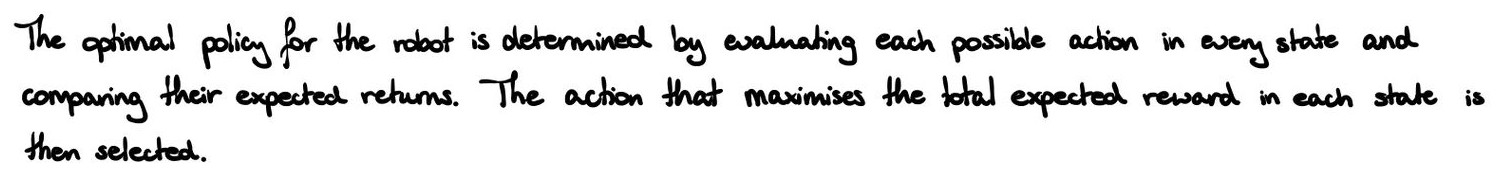

### 3.3 Division of Work

#### Question 23

|          Component          |    Eva    |  Iasonas  |    Guy    |   Miłosz  |
|-----------------------------|-----------|-----------|-----------|----------|
| Code (design)               |    20%    |    30%    |    25%    |    25%   |
| Code (implementation)       |    25%    |    25%    |    30%    |    20%   |
| Code (validation)           |    30%    |    20%    |    25%    |    25%   |
| Experiments (execution)     |    25%    |    25%    |    25%    |    25%   |
| Experiments (analysis)      |    20%    |    30%    |    25%    |    25%   |
| Experiments (visualisation) |    25%    |    25%    |    20%    |    30%   |
| Report (original draft)     |    30%    |    20%    |    25%    |    25%   |
| Report (reviewing & editing)|    25%    |    25%    |    25%    |    25%   |

### References

Generative AI was used for help with the following:
- **Markdown**: for example, making tables in Markdown
- The Held-Karp verification helper (mentioned in the code)
- Assistance with debugging and writing unit tests
- Suggestions (mentioned in the code) and verification that the code is correct
- Assistance for refinement of plots via `matplotlib`
- Used for assistance with documentation such as comments and docstrings

# Assignment Breakdown

| Question | Type | Task | Points |
|----------|------|------|--------|
| **2.1 Development** | **Code + Write** | **Implement exploration strategies, agent cycle, stopping criterion, learning algorithms; verify learning occurs** | **21** |
| Q1 | Code + Write | Implement `random()`, `e_greedy()`, `boltzmann()` in `ExplorationStrategy`; explain implementations and exploration/exploitation handling | 4 |
| Q2 | Code + Write | Implement the agent cycle (select action → execute → update Q-table → repeat); explain why each step is necessary | 3 |
| Q3 | Code + Write | Implement stopping criterion (total steps across episodes ≥ n); verify with n = 30,000 | 2 |
| Q4 | Code + Write | Plot average episode length over 10 runs for each maze; show agent does *not* learn (no learner yet); include uncertainty | 4 |
| Q5 | Code + Write | Implement `learn()` for `QLearning` and `SARSA` using Equations 1.1 and 1.2; set α = 0.7, γ = 0.9, ε = 0.1 | 2 |
| Q6 | Code + Write | Plot average episode length over 10 runs for each algorithm/maze; show agent *does* learn; include uncertainty | 4 |
| Q7 | Write | Compare Q-Learning vs SARSA from plots; explain differences with reference to update equations | 2 |
| **2.2 Optimization** | **Code + Write** | **Tune ε, T, and α; compare exploration strategies** | **10** |
| Q8 | Code + Write | Test at least 5 values of ε ∈ [0, 1]; plot 10-run averages; explain observations | 3 |
| Q9 | Write | Discuss trade-offs between high and low ε | 1 |
| Q10 | Code + Write | Test at least 5 values of T for Boltzmann; discuss trade-offs | 2 |
| Q11 | Code + Write | Compare all three exploration strategies; identify best performer and explain why | 2 |
| Q12 | Code + Write | Test at least 5 values of α ∈ [0, 1]; plot and explain observations | 2 |
| **2.3 Introducing More Rewards** | **Code + Write** | **Add competing reward; analyze convergence issues; derive critical γ** | **8** |
| Q13 | Code + Write | Add reward of 5 at (9, 0); observe and explain behavior | 1 |
| Q14 | Code + Write | Test if SARSA solves the problem; compare and explain | 2 |
| Q15 | Code + Write | Mitigate problem via ε-decay or similar; cite literature; show convergence plot | 3 |
| Q16 | Code + Write | Find γ threshold where smaller reward becomes optimal; confirm experimentally and derive analytically | 2 |
| **3.1 Reflection** | **Write** | **Discuss limitations of greedy policies and reward hacking** | **5** |
| Q17 | Write | Give at least one downside of purely greedy action selection | 1 |
| Q18 | Write | Discuss when/why reward functions can cause societal problems (reward hacking, misalignment) | 2 |
| Q19 | Write | Propose practical solutions to reward function problems | 2 |
| **3.2 Pen and Paper** | **Write** | **MDP modeling and policy evaluation (exam prep)** | **8** |
| Q20 | Write | Draw MDP transition graph for fruit-shopping robot scenario; label states, actions, probabilities | 3 |
| Q21 | Write | Compute $v_2(s)$ via Bellman equation for given policy with γ = 0.9; show $v_0$, $v_1$, $v_2$ | 3 |
| Q22 | Write | Explain (no calculation) how to determine the optimal policy | 2 |
| **3.3 Division of Work** | **Write** | **Document group contributions** | **0** |
| Q23 | Write | Fill in contribution table | 0 |
| **Total** | | | **52** |